# Importe

In [1]:
import pandas as pd
import numpy as np
from itertools import product
from multiprocessing import Pool, cpu_count

## DataFrame laden

In [17]:
# Load the CSV file
file_path = 'Ergebnisse/LP_Verständlichkeit.csv'
df_orginal = pd.read_csv(file_path, header=None)

# Binäre Umwandlung (z.B., alle Werte > 0 zu 1, sonst 0)
df = (df_orginal > 0).astype(int)

# Selbe df spseter wichtig
df_binaer = (df_orginal > 0).astype(int)

for i in range(min(df.shape)):
    df.iat[i, i] = 1

# Display the first few rows of the matrix to understand its structure
df.head()

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
0,1,0,0,0,1,0,0,1,0,1,...,1,1,1,1,0,0,1,1,0,1
1,1,1,0,1,0,1,1,1,0,0,...,1,0,1,0,1,0,0,1,1,0
2,1,0,1,0,1,0,0,1,1,1,...,0,1,1,0,0,1,1,1,0,0
3,1,1,1,1,0,1,1,1,1,1,...,0,1,0,1,0,0,0,0,1,1
4,0,0,1,0,1,1,1,1,0,0,...,0,0,1,1,1,1,1,1,1,1


# Transitivität & Symmetrie ueberpruefen mit Bereitstellung aller derzeitig ungenutzten Kerne
### (extra Notwendig:) multiprocessing & itertools
### Funktionen

#### Transitivität

In [ ]:
# Funktion zur Überprüfung der Transitivität einer binären Matrix
def is_transitive(matrix):
    n = matrix.shape[0]
    for i in range(n):
        for j in range(n):
            if matrix.iloc[i, j] == 1:
                for k in range(n):
                    if matrix.iloc[j, k] == 1 and matrix.iloc[i, k] != 1:
                        return False
    return True

In [ ]:
# Hilfsfunktion für parallele Verarbeitung
def process_submatrix_transitive(args):
    matrix, i, j, size = args
    submatrix = matrix.iloc[i:i+size, j:j+size]
    if is_transitive(submatrix):
        return ((i, i+size), (j, j+size))
    return None

In [ ]:
# Funktion zur Identifikation transitiver Teilbereiche in der Matrix (mit Parallelisierung)
def find_transitive_submatrices(matrix, min_size=2, max_size=5):
    n = matrix.shape[0]
    transitive_submatrices = []
    tasks = []
    
    # Erstelle eine Liste von Aufgaben für parallele Verarbeitung
    for size in range(min_size, min(max_size, n) + 1):
        for i, j in product(range(n - size + 1), repeat=2):
            tasks.append((matrix, i, j, size))
    
    # Parallele Verarbeitung der Aufgaben
    with Pool(processes=cpu_count()) as pool:
        results = pool.map(process_submatrix_transitive, tasks)
    
    # Filtere die gültigen Ergebnisse
    transitive_submatrices = [res for res in results if res is not None]
    
    return transitive_submatrices

#### Symmetrie

In [ ]:
# Funktion zur Überprüfung der Symmetrie einer Matrix
def is_symmetric(matrix):
    return matrix.equals(matrix.transpose())

In [ ]:
# Hilfsfunktion für parallele Verarbeitung
def process_submatrix_symmetric(args):
    matrix, i, j, size = args
    submatrix = matrix.iloc[i:i+size, j:j+size]
    if is_symmetric(submatrix):
        return ((i, i+size), (j, j+size))
    return None

In [ ]:
# Funktion zur Identifikation symmetrischer Teilbereiche in der Matrix (mit Parallelisierung)
def find_symmetric_submatrices(matrix, min_size=2, max_size=5):
    n = matrix.shape[0]
    symmetric_submatrices = []
    tasks = []
    
    # Erstelle eine Liste von Aufgaben für parallele Verarbeitung
    for size in range(min_size, min(max_size, n) + 1):
        for i, j in product(range(n - size + 1), repeat=2):
            tasks.append((matrix, i, j, size))
    
    # Parallele Verarbeitung der Aufgaben
    with Pool(processes=cpu_count()) as pool:
        results = pool.map(process_submatrix_symmetric, tasks)
    
    # Filtere die gültigen Ergebnisse
    symmetric_submatrices = [res for res in results if res is not None]
    
    return symmetric_submatrices

### Anwendung

In [ ]:
# Suche nach transitiven Teilbereichen (Größen von 2x2 bis 5x5)
transitive_submatrices = find_transitive_submatrices(df, max_size=df.shape[1])

# Ausgabe der gefundenen transitiven Teilbereiche
pd.DataFrame(transitive_submatrices, columns=['Row Range', 'Column Range']).head()

In [ ]:
# Suche nach symmetrischen Teilbereichen (Größen von 2x2 bis 5x5)
symmetric_submatrices = find_symmetric_submatrices(df, max_size=df.shape[1])

# Ausgabe der gefundenen symmetrischen Teilbereiche
pd.DataFrame(symmetric_submatrices, columns=['Row Range', 'Column Range']).head()

In [ ]:
# Finde Überschneidungen zwischen symmetrischen und transitiven Teilbereichen
symmetric_set = set(symmetric_submatrices)
transitive_set = set(transitive_submatrices)

# Finde die gemeinsamen Teilbereiche (Schnittmenge der beiden Mengen)
overlapping_submatrices = symmetric_set & transitive_set

# Ausgabe der gemeinsamen symmetrischen und transitiven Teilbereiche
overlapping_submatrices

### Selbe Filterung, jedoch anders vorgegangen, um diese vorzunehmen, und zwar mittels von Prinzipien der "vectorize operations".
Darauf bin ich tatsächlich über einem Post in LinkedIn gekommen und ist schneller bei diesem Datensatz gegenüber von multiprocessing

### Funktionen

In [3]:
# Vektorisierte Symmetrieprüfung
def is_symmetric_vectorized(matrix):
    return np.array_equal(matrix, matrix.T)

In [4]:
# Vektorisierte Transitivitätsprüfung
def is_transitive_vectorized(matrix):
    # Stellt sicher, dass die Matrix boolesch interpretiert wird
    #matrix = (matrix > 0).astype(int)
    
    # Berechne die quadratische Matrix
    #matrix_squared = np.dot(matrix, matrix) > 0
    #print(np.dot(matrix, matrix) > 0)
    
    # Prüfe, ob alle Pfade aus matrix_squared auch in der ursprünglichen Matrix sind
    #return np.all((matrix_squared & (matrix == 0)) == False)
    matrix_squared = np.dot(matrix, matrix) > 0
    return np.all((matrix_squared & (matrix == 0)) == False)

In [5]:
# Sliding Window zur Suche nach symmetrischen und transitiven Teilmatrizen
def find_symmetric_transitive_submatrices(matrix, min_size=2, max_size=10):
    n = matrix.shape[0]
    symmetric_transitive_submatrices = []
    
    for size in range(min_size, min(max_size, n) + 1):
        for i in range(n - size + 1):
            for j in range(n - size + 1):
                submatrix = matrix[i:i+size, j:j+size]
                if is_symmetric_vectorized(submatrix) and is_transitive_vectorized(submatrix):
                    symmetric_transitive_submatrices.append(((i, i+size), (j, j+size)))
                    
    return symmetric_transitive_submatrices

### Anwendung

In [6]:
# Konvertiere die DataFrame-Matrix in ein NumPy-Array für vektorisierte Operationen
matrix_np = df.to_numpy()

# Finde symmetrische und transitive Teilmatrizen mit vektorisierten Operationen (bis Größe 10)
symmetric_transitive_submatrices_vec = find_symmetric_transitive_submatrices(matrix_np, min_size=2, max_size=df.shape[1])

# Ausgabe der ersten 5 gefundenen Bereiche
symmetric_transitive_submatrices_vec[:5]

[((0, 2), (2, 4)),
 ((0, 2), (4, 6)),
 ((0, 2), (12, 14)),
 ((0, 2), (17, 19)),
 ((0, 2), (19, 21))]

In [7]:
# Filtere symmetrische und transitive Teilmatrizen mit denselben Zeilen- und Spaltennummern
symmetric_transitive_same_rows_cols = [
    (rows, cols) for rows, cols in symmetric_transitive_submatrices_vec if rows == cols
]

symmetric_transitive_same_rows_cols

[((1, 3), (1, 3)),
 ((3, 5), (3, 5)),
 ((10, 12), (10, 12)),
 ((16, 18), (16, 18)),
 ((19, 21), (19, 21)),
 ((21, 23), (21, 23)),
 ((25, 27), (25, 27)),
 ((26, 28), (26, 28)),
 ((27, 29), (27, 29)),
 ((28, 30), (28, 30)),
 ((34, 36), (34, 36)),
 ((35, 37), (35, 37)),
 ((37, 39), (37, 39)),
 ((38, 40), (38, 40)),
 ((39, 41), (39, 41)),
 ((40, 42), (40, 42)),
 ((42, 44), (42, 44)),
 ((45, 47), (45, 47)),
 ((46, 48), (46, 48)),
 ((49, 51), (49, 51)),
 ((50, 52), (50, 52)),
 ((51, 53), (51, 53)),
 ((54, 56), (54, 56)),
 ((55, 57), (55, 57)),
 ((59, 61), (59, 61)),
 ((63, 65), (63, 65)),
 ((65, 67), (65, 67)),
 ((66, 68), (66, 68)),
 ((67, 69), (67, 69)),
 ((68, 70), (68, 70)),
 ((69, 71), (69, 71)),
 ((70, 72), (70, 72)),
 ((71, 73), (71, 73)),
 ((74, 76), (74, 76)),
 ((77, 79), (77, 79)),
 ((78, 80), (78, 80)),
 ((79, 81), (79, 81)),
 ((80, 82), (80, 82)),
 ((83, 85), (83, 85)),
 ((84, 86), (84, 86)),
 ((91, 93), (91, 93)),
 ((92, 94), (92, 94)),
 ((93, 95), (93, 95)),
 ((94, 96), (94, 96

In [8]:
# Konvertiere die DataFrame-Matrix in ein NumPy-Array für vektorisierte Operationen
binaer_matrix_np = df_binaer.to_numpy()

# Finde symmetrische und transitive Teilmatrizen mit vektorisierten Operationen (bis Größe 10)
binaer_symmetric_transitive_submatrices_vec = find_symmetric_transitive_submatrices(binaer_matrix_np, min_size=2, max_size=df.shape[1])

# Ausgabe der ersten 5 gefundenen Bereiche
binaer_symmetric_transitive_submatrices_vec[:5]

[((0, 2), (1, 3)),
 ((0, 2), (2, 4)),
 ((0, 2), (4, 6)),
 ((0, 2), (12, 14)),
 ((0, 2), (17, 19))]

In [9]:
# Filtere symmetrische und transitive Teilmatrizen mit denselben Zeilen- und Spaltennummern
binaer_symmetric_transitive_same_rows_cols = [
    (rows, cols) for rows, cols in binaer_symmetric_transitive_submatrices_vec if rows == cols
]

binaer_symmetric_transitive_same_rows_cols

[((1, 3), (1, 3)),
 ((3, 5), (3, 5)),
 ((21, 23), (21, 23)),
 ((25, 27), (25, 27)),
 ((27, 29), (27, 29)),
 ((40, 42), (40, 42)),
 ((42, 44), (42, 44)),
 ((45, 47), (45, 47)),
 ((46, 48), (46, 48)),
 ((51, 53), (51, 53)),
 ((63, 65), (63, 65)),
 ((66, 68), (66, 68)),
 ((67, 69), (67, 69)),
 ((77, 79), (77, 79)),
 ((80, 82), (80, 82)),
 ((83, 85), (83, 85)),
 ((91, 93), (91, 93)),
 ((93, 95), (93, 95)),
 ((99, 101), (99, 101)),
 ((103, 105), (103, 105))]

In [10]:
end_list=list(set(symmetric_transitive_same_rows_cols) - set(binaer_symmetric_transitive_same_rows_cols))
end_list

[((66, 69), (66, 69)),
 ((27, 30), (27, 30)),
 ((68, 70), (68, 70)),
 ((69, 72), (69, 72)),
 ((37, 39), (37, 39)),
 ((71, 73), (71, 73)),
 ((67, 70), (67, 70)),
 ((70, 72), (70, 72)),
 ((65, 67), (65, 67)),
 ((34, 36), (34, 36)),
 ((54, 56), (54, 56)),
 ((28, 30), (28, 30)),
 ((78, 80), (78, 80)),
 ((99, 102), (99, 102)),
 ((95, 97), (95, 97)),
 ((97, 99), (97, 99)),
 ((16, 18), (16, 18)),
 ((84, 86), (84, 86)),
 ((59, 61), (59, 61)),
 ((19, 21), (19, 21)),
 ((39, 41), (39, 41)),
 ((92, 94), (92, 94)),
 ((50, 52), (50, 52)),
 ((10, 12), (10, 12)),
 ((100, 102), (100, 102)),
 ((55, 57), (55, 57)),
 ((70, 73), (70, 73)),
 ((74, 76), (74, 76)),
 ((69, 71), (69, 71)),
 ((49, 51), (49, 51)),
 ((94, 96), (94, 96)),
 ((35, 37), (35, 37)),
 ((26, 28), (26, 28)),
 ((79, 81), (79, 81)),
 ((38, 40), (38, 40)),
 ((94, 97), (94, 97))]

In [11]:
length=len(end_list)
for l in range(length):
    print(df_orginal.iloc[end_list[l][0][0]:end_list[l][0][1], end_list[l][0][0]:end_list[l][0][1]], "\n")

print(df_orginal.iloc[94:97, 94:97])

    66  67  68
66   0   0   2
67   0   0   0
68   1   0   0 

    27  28  29
27   0   0   0
28   0   0   1
29   0   1   0 

    68  69
68   0   1
69   1   0 

    69  70  71
69   0   1   1
70   1   0   1
71   2   1   0 

    37  38
37   0   1
38   1   0 

    71  72
71   0   1
72   1   0 

    67  68  69
67   0   0   0
68   0   0   1
69   0   1   0 

    70  71
70   0   1
71   1   0 

    65  66
65   0   1
66   3   0 

    34  35
34   0   1
35   1   0 

    54  55
54   0   1
55   1   0 

    28  29
28   0   1
29   1   0 

    78  79
78   0   1
79   1   0 

     99   100  101
99     0    0    0
100    0    0    1
101    0    1    0 

    95  96
95   0   1
96   1   0 

    97  98
97   0   1
98   1   0 

    16  17
16   0   1
17   1   0 

    84  85
84   0   1
85   1   0 

    59  60
59   0   3
60   1   0 

    19  20
19   0   1
20   1   0 

    39  40
39   0   1
40   2   0 

    92  93
92   0   1
93   1   0 

    50  51
50   0   1
51   1   0 

    10  11
10   0   1
11   1   0 

     100 

In [15]:
# Array für die gesammelten DataFrame-Ausschnitte
intervalle = []

# Schleife zum Sammeln der DataFrame-Ausschnitte
for l in range(length):
    ausschnitt = df_original.iloc[
        end_list[l][0][0]:end_list[l][0][1],
        end_list[l][0][0]:end_list[l][0][1]
    ]
    intervalle.append(ausschnitt.values)  # .values konvertiert in ein NumPy-Array

# Optional: In ein NumPy-Array konvertieren, falls einheitliche Form
intervalle = np.array(intervalle, dtype=object)
intervalle

NameError: name 'df_original' is not defined

In [13]:
# Array für die gesammelten DataFrame-Ausschnitte
intervalle = []

# Schleife zum Sammeln der DataFrame-Ausschnitte
for l in range(length):
    ausschnitt = df_original.iloc[
        end_list[l][0][0]:end_list[l][0][1],
        end_list[l][0][0]:end_list[l][0][1]
    ]
    intervalle.append(ausschnitt.values)  # .values konvertiert in ein NumPy-Array

# Optional: In ein NumPy-Array konvertieren, falls einheitliche Form
intervalle = np.array(intervalle, dtype=object)

# Gegebene Intervalle als Liste von Tupeln
intervalle = [
    (66, 69), (27, 30), (68, 70), (69, 72), (37, 39), (71, 73),
    (67, 70), (70, 72), (65, 67), (34, 36), (54, 56), (28, 30),
    (78, 80), (99, 102), (95, 97), (97, 99), (16, 18), (84, 86),
    (59, 61), (19, 21), (39, 41), (92, 94), (50, 52), (10, 12),
    (100, 102), (55, 57), (70, 73), (74, 76), (69, 71), (49, 51),
    (94, 96), (35, 37), (26, 28), (79, 81), (38, 40), (94, 97)
]

# Hilfsfunktion zum Überprüfen von Überlappungen
def ueberlappen(interval1, interval2):
    return interval1[1] >= interval2[0] and interval2[1] >= interval1[0]

# Äquivalenzklassen erstellen
def bilde_aequivalenzklassen(intervalle):
    intervalle = sorted(intervalle)
    klassen = []

    while intervalle:
        aktuelle_klasse = [intervalle.pop(0)]
        i = 0

        while i < len(intervalle):
            if any(ueberlappen(interval, intervalle[i]) for interval in aktuelle_klasse):
                aktuelle_klasse.append(intervalle.pop(i))
            else:
                i += 1

        klassen.append(aktuelle_klasse)

    return klassen

# Äquivalenzklassen berechnen
aequivalenzklassen = bilde_aequivalenzklassen(intervalle)

# Ausgabe als DataFrame für Übersicht
df_aequivalenzklassen = pd.DataFrame({'Äquivalenzklasse': range(1, len(aequivalenzklassen)+1), 'Intervalle': aequivalenzklassen})

print(df_aequivalenzklassen)

    Äquivalenzklasse                                         Intervalle
0                  1                                         [(10, 12)]
1                  2                                         [(16, 18)]
2                  3                                         [(19, 21)]
3                  4                     [(26, 28), (27, 30), (28, 30)]
4                  5  [(34, 36), (35, 37), (37, 39), (38, 40), (39, ...
5                  6                               [(49, 51), (50, 52)]
6                  7                               [(54, 56), (55, 57)]
7                  8                                         [(59, 61)]
8                  9  [(65, 67), (66, 69), (67, 70), (68, 70), (69, ...
9                 10                                         [(74, 76)]
10                11                               [(78, 80), (79, 81)]
11                12                                         [(84, 86)]
12                13  [(92, 94), (94, 96), (94, 97), (95, 97), (

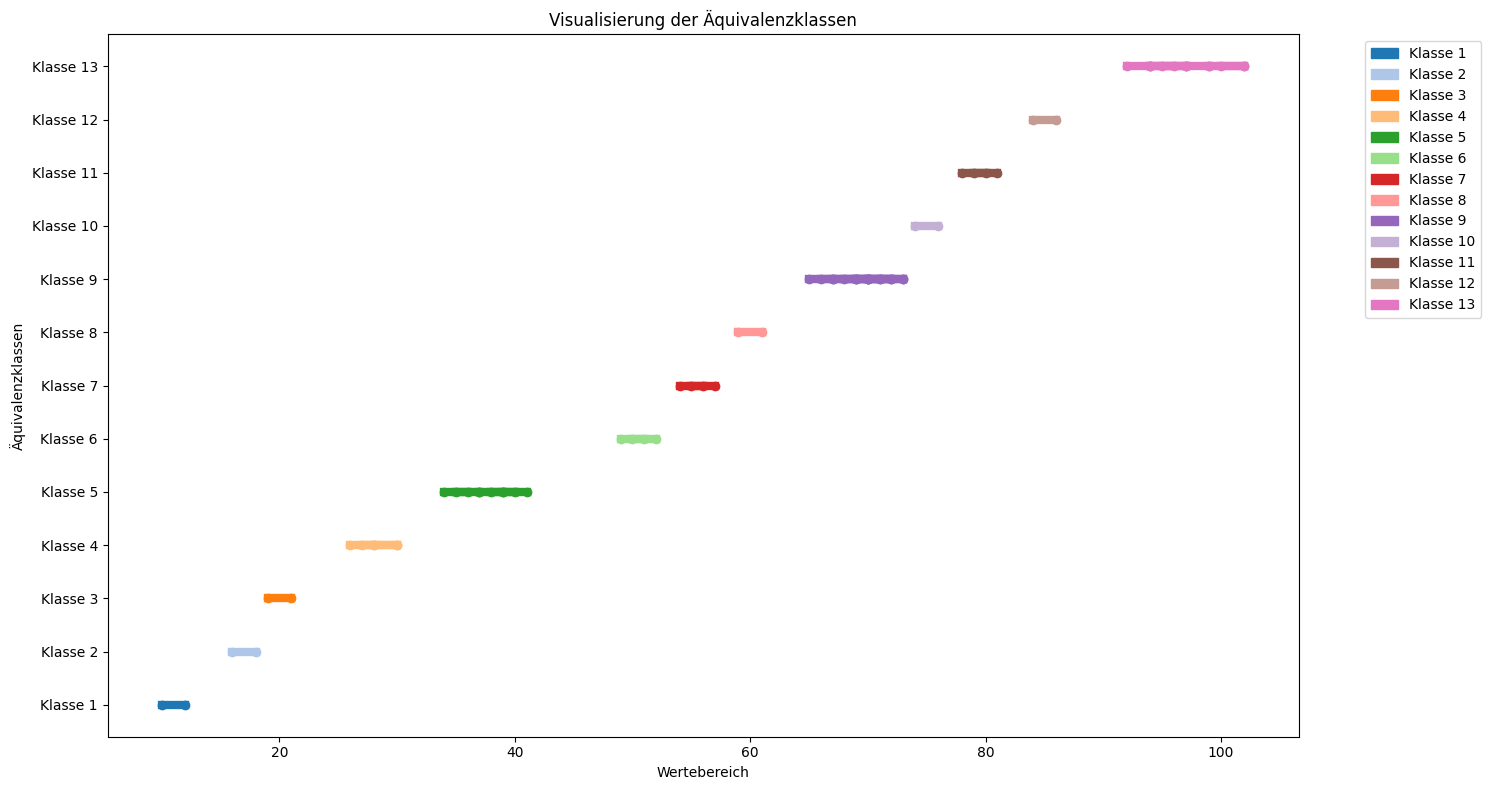

In [14]:
# Visualisierung der Äquivalenzklassen als Balkendiagramm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Farben für verschiedene Äquivalenzklassen
farben = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(15, 8))

# Plot der Intervalle für jede Äquivalenzklasse
for i, klasse in enumerate(aequivalenzklassen):
    for interval in klasse:
        ax.plot([interval[0], interval[1]], [i, i], marker='o', linewidth=6, color=farben[i % len(farben)])

# Achsentitel und Beschriftungen
ax.set_yticks(range(len(aequivalenzklassen)))
ax.set_yticklabels([f'Klasse {i+1}' for i in range(len(aequivalenzklassen))])
ax.set_xlabel('Wertebereich')
ax.set_ylabel('Äquivalenzklassen')
ax.set_title('Visualisierung der Äquivalenzklassen')

# Legende hinzufügen
legenden_patches = [mpatches.Patch(color=farben[i % len(farben)], label=f'Klasse {i+1}') for i in range(len(aequivalenzklassen))]
ax.legend(handles=legenden_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()